In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "id": [1, 2, 3, 4, 5, 5, 6],  # 👈 duplicado (id=5)
    "edad": [25, "30", 35, None, "cuarenta", 28, 22],  # 👈 error formato + null
    "salario": [3000, 4000, None, 5000, "6000$", 4000, 3200],  # 👈 null + formato
    "gastos": [2000, 2500, 2700, None, 3000, 2500, "dos mil"],  # 👈 null + texto
    "departamento": ["IT", "HR", "IT", "FIN", "HR", "HR", None]  # 👈 null
}

df = pd.DataFrame(data)

print(df)

   id      edad salario   gastos departamento
0   1        25    3000     2000           IT
1   2        30    4000     2500           HR
2   3        35    None     2700           IT
3   4      None    5000     None          FIN
4   5  cuarenta   6000$     3000           HR
5   5        28    4000     2500           HR
6   6        22    3200  dos mil         None


In [3]:
df.shape

(7, 5)

In [4]:
df.dtypes

id               int64
edad            object
salario         object
gastos          object
departamento    object
dtype: object

In [5]:
df = df.drop_duplicates("id")
df

,id,edad,salario,gastos,departamento
0,1,25,3000,2000,IT
1,2,30,4000,2500,HR
2,3,35,None,2700,IT
3,4,None,5000,None,FIN
4,5,cuarenta,6000$,3000,HR
6,6,22,3200,dos mil,None


In [6]:
df["edad"] = df["edad"].replace("cuarenta", 40)
df

,id,edad,salario,gastos,departamento
0,1,25,3000,2000,IT
1,2,30,4000,2500,HR
2,3,35,None,2700,IT
3,4,None,5000,None,FIN
4,5,40,6000$,3000,HR
6,6,22,3200,dos mil,None


In [7]:
df["salario"] = df["salario"].replace("6000$", 6000)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20084\2158334977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["salario"] = df["salario"].replace("6000$", 6000)


,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000,IT
1,2,30,4000.0,2500,HR
2,3,35,NaN,2700,IT
3,4,None,5000.0,None,FIN
4,5,40,6000.0,3000,HR
6,6,22,3200.0,dos mil,None


In [8]:
df["gastos"] = df["gastos"].replace("dos mil", 2000)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20084\51898630.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gastos"] = df["gastos"].replace("dos mil", 2000)


,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000.0,IT
1,2,30,4000.0,2500.0,HR
2,3,35,NaN,2700.0,IT
3,4,None,5000.0,NaN,FIN
4,5,40,6000.0,3000.0,HR
6,6,22,3200.0,2000.0,None


In [10]:
df['edad'].fillna(df['edad'].median(), inplace=True)
df

,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000.0,IT
1,2,30,4000.0,2500.0,HR
2,3,35,NaN,2700.0,IT
3,4,30.0,5000.0,NaN,FIN
4,5,40,6000.0,3000.0,HR
6,6,22,3200.0,2000.0,None


In [11]:
df['salario'].fillna(df['salario'].mean(), inplace=True)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20084\2645982434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['salario'].fillna(df['salario'].mean(), inplace=True)


,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000.0,IT
1,2,30,4000.0,2500.0,HR
2,3,35,4240.0,2700.0,IT
3,4,30.0,5000.0,NaN,FIN
4,5,40,6000.0,3000.0,HR
6,6,22,3200.0,2000.0,None


In [12]:
df['gastos'].fillna(df['gastos'].mean(), inplace=True)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20084\3315856522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gastos'].fillna(df['gastos'].mean(), inplace=True)


,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000.0,IT
1,2,30,4000.0,2500.0,HR
2,3,35,4240.0,2700.0,IT
3,4,30.0,5000.0,2440.0,FIN
4,5,40,6000.0,3000.0,HR
6,6,22,3200.0,2000.0,None


In [13]:
df['departamento'].fillna("desconocido", inplace=True)
df

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20084\1555533279.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['departamento'].fillna("desconocido", inplace=True)


,id,edad,salario,gastos,departamento
0,1,25,3000.0,2000.0,IT
1,2,30,4000.0,2500.0,HR
2,3,35,4240.0,2700.0,IT
3,4,30.0,5000.0,2440.0,FIN
4,5,40,6000.0,3000.0,HR
6,6,22,3200.0,2000.0,desconocido


In [14]:
df["edad"] = df["edad"].astype(int)
df.dtypes

id                int64
edad              int32
salario         float64
gastos          float64
departamento     object
dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            6 non-null      int64  
 1   edad          6 non-null      int32  
 2   salario       6 non-null      float64
 3   gastos        6 non-null      float64
 4   departamento  6 non-null      object 
dtypes: float64(2), int32(1), int64(1), object(1)
memory usage: 264.0+ bytes


In [19]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               id      edad   salario    gastos
id       1.000000  0.081832  0.368008  0.168680
edad     0.081832  1.000000  0.872551  0.983380
salario  0.368008  0.872551  1.000000  0.891602
gastos   0.168680  0.983380  0.891602  1.000000


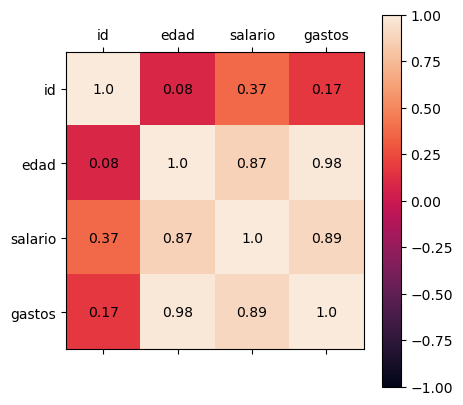

In [35]:
plt.matshow(corr_matrix, cmap='rocket', vmin=-1, vmax=1)
plt.xticks(range(4), corr_matrix.columns)
plt.yticks(range(4), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(i, j, round(corr_matrix.iloc[i, j], 2), ha='center', va='center')

plt.colorbar()
plt.show()


Text(0.5, 0, 'Salario')

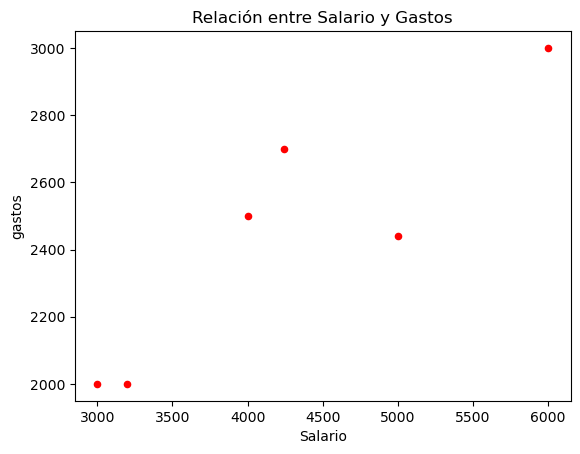

In [43]:
df.plot(kind='scatter', x='salario', y='gastos', color='red')
plt.title('Relación entre Salario y Gastos')
plt.xlabel('Salario')